In [266]:
# 08/2025
###########################################################################################
# using linear model to test group difference
#	Testing group difference
#   Plotting results
#   Diagnostics of the model
#   non-parametric alternative if necessary (not yet implemented)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [71]:
curProject = 'HD'
curRegion = 'CST'  # CS, CSpreCS, CST
curRoot = 'C'  # 'C' or 'D'
curDistType = 'max'           ############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################
curNeig = 30 # 10, 30, 60     ############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################

################################  Read the CSV file into a DataFrame  ################################
file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_combined_k{curNeig}_{curDistType}.csv'
print(file_path)

merged_info = pd.read_csv(file_path)
print(len(merged_info))
#print("Data types:\n", df_loaded.dtypes)

#################################  remove outliers identified below  ##################################
if curRegion=='CSpreCS' and curDistType=='min':
    merged_info = merged_info[~merged_info['subjName'].isin(['L010697MHU','flip-R010697MHU','L010172MHU'])]
if curRegion=='CSpreCS' and curDistType=='max':
    merged_info = merged_info[~merged_info['subjName'].isin(['L010697MHU','flip-R010697MHU'])]    


#if curRegion=='CS' and curDistType=='max':  # ORIGINAL results of iso2 min K30 used this line !
if curRegion=='CS':    
    merged_info = merged_info[~merged_info['subjName'].isin(['L010697MHU', 'flip-R010697MHU'])]

if (curRegion=='CST') & (curDistType=='min'):    
    merged_info = merged_info[~merged_info['subjName'].isin(['L010172MHU'])]
#######################################################################################################

# Add numeric columns for tests
merged_info['Sex_num'] = merged_info['Sex'].map({'M': 0, 'F': 1})    # Create the new column 'Category_num'
merged_info['Hemisphere_num'] = merged_info['Hemisphere'].map({'Left': 1, 'Right': 2})    # Create the new column 'Category_num'

# Make sure categorical variables are treated as such
merged_info['Diag'] = merged_info['Diag'].astype('category')
merged_info['Sex'] = merged_info['Sex'].astype('category')
merged_info['Study'] = merged_info['Study'].astype('category')

#print(merged_info['Study'])
print(merged_info['Study'].unique())
print(merged_info['Study'].dtype)
#merged_info.isna().sum()
nan_counts = merged_info.isna().sum().sort_values(ascending=False)
#print(nan_counts)

C:\B_projWIP\proj_HD\Analysis_2025\CST_combined_k30_max.csv
42
['MOTOHD']
Categories (1, object): ['MOTOHD']
category


In [61]:
merged_info.columns

Index(['subjName', 'iso1', 'iso2', 'iso3', 'iso4', 'iso5', 'iso6', 'UMAP1_U1',
       'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'SubjID',
       'Study', 'Hemisphere', 'Age', 'Diag', 'Sex', 'CAG', 'UHDRS',
       'Pyramidal', 'CAG_normalAllele', 'Sex_num', 'Hemisphere_num'],
      dtype='object')

In [73]:
##############  create a new column to classify CAG  ##############
# Meaning of bins:  1: 36–39  2: 40–42  3: 43–46  4: >46
bins = [36, 39, 42, 46, float('inf')]
labels = [1, 2, 3, 4]

merged_info['CAG_class'] = pd.cut(merged_info['CAG'], bins=bins, labels=labels, right=True)

In [75]:
print(merged_info.columns)

Index(['subjName', 'iso1', 'iso2', 'iso3', 'iso4', 'iso5', 'iso6', 'UMAP1_U1',
       'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'SubjID',
       'Study', 'Hemisphere', 'Age', 'Diag', 'Sex', 'CAG', 'UHDRS',
       'Pyramidal', 'CAG_normalAllele', 'Sex_num', 'Hemisphere_num',
       'CAG_class'],
      dtype='object')


In [77]:
################################  Data Selection  ################################
left_hem = merged_info[merged_info['Hemisphere'] == 'Left']
right_hem = merged_info[merged_info['Hemisphere'] == 'Right']
controls = merged_info[merged_info['Diag'] == 'T'] 

WINHD = merged_info[(merged_info['Study']=='WINHD')]
MOTOHD = merged_info[(merged_info['Study']=='MOTOHD')]
HDTRACK = merged_info[(merged_info['Study']=='HDTRACK')]

HDTRACK_MOTOHD = merged_info[merged_info['Study'].isin(['HDTRACK', 'MOTOHD'])]
HDTRACK_MOTOHD['Study'] = HDTRACK_MOTOHD['Study'].cat.remove_unused_categories()   # important to remove unused category for stats
#print(HDTRACK_MOTOHD.Study)

WINHD['Diag'] = WINHD['Diag'].cat.remove_unused_categories()
MOTOHD['Diag'] = MOTOHD['Diag'].cat.remove_unused_categories()
HDTRACK['Diag'] = HDTRACK['Diag'].cat.remove_unused_categories()
print(HDTRACK['Diag'].unique())

WINHD_left = WINHD[WINHD['Hemisphere'] == 'Left']
WINHD_right = WINHD[WINHD['Hemisphere'] == 'Right']
MOTOHD_left = MOTOHD[MOTOHD['Hemisphere'] == 'Left']
MOTOHD_right = MOTOHD[MOTOHD['Hemisphere'] == 'Right']
HDTRACK_left = HDTRACK[HDTRACK['Hemisphere'] == 'Left']
HDTRACK_right = HDTRACK[HDTRACK['Hemisphere'] == 'Right']


[], Categories (0, object): []


In [49]:
print(MOTOHD)

           subjName      iso1      iso2      iso3      iso4      iso5  \
0        L010017MHU -0.166487 -2.490120 -0.347840 -0.730658  1.002554   
1        L010023MHU -2.492779 -0.137512 -0.106463 -1.888831  1.041870   
2        L010052MHU -2.576504  0.366856 -0.402219  0.265657  0.076691   
3        L010086MHU  1.295097 -0.010308  0.366572 -0.335014 -0.761850   
4        L010172MHU -2.207362  5.770134  1.176302 -0.666594  0.155686   
5        L010174MHU -1.807275  0.328203 -0.046014  0.067392  1.067100   
6        L010179MHU  2.660657 -0.107188 -1.026340  0.383359 -0.344674   
7        L010210MHU  2.066422 -0.859005  0.329081  0.632004 -0.835180   
8        L010218MHU -0.142882 -1.022363  3.111458 -0.324938  1.312660   
9        L010264MHU  1.503025  0.960145  0.244767  2.403510  0.862122   
10       L010290MHU  0.671188  0.083463  1.393797 -0.836981  0.959019   
11       L010339MHU  2.715469  0.403974 -0.389942 -0.318270  0.126315   
12       L010408MHU -2.633883  1.657744  0.939065  

In [79]:
#################################  find outliers  ###############################

def find_outliers(df, group_cols, value_col):
    """
    Identify outliers per group using 1.5*IQR rule.
    Returns a DataFrame of outlier rows.
    """
    outliers = []
    grouped = df.groupby(group_cols)
    for keys, grp in grouped:
        q1 = grp[value_col].quantile(0.25)
        q3 = grp[value_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (grp[value_col] < lower) | (grp[value_col] > upper)
        outliers.append(grp.loc[mask])
    return pd.concat(outliers)

outliers = find_outliers(MOTOHD, ['Study', 'Diag'], 'iso1')  ## modify database depending on visualization  
print(outliers)

Empty DataFrame
Columns: [subjName, iso1, iso2, iso3, iso4, iso5, iso6, UMAP1_U1, UMAP1_U2, UMAP1_U3, UMAP2_U3, UMAP1_U4, UMAP2_U4, SubjID, Study, Hemisphere, Age, Diag, Sex, CAG, UHDRS, Pyramidal, CAG_normalAllele, Sex_num, Hemisphere_num, CAG_class]
Index: []

[0 rows x 26 columns]


C:\Users\joyca\AppData\Local\Temp\ipykernel_14604\3128691629.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols)


C:\Users\joyca\AppData\Local\Temp\ipykernel_10056\3838847552.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HDTRACK['Dataset'] = 'HDTRACK'
C:\Users\joyca\AppData\Local\Temp\ipykernel_10056\3838847552.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  WINHD['Dataset'] = 'WINHD'
C:\Users\joyca\AppData\Local\Temp\ipykernel_10056\3838847552.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

C:\B_projWIP\proj_HD\Analysis_2025\Plots\HD_CS_min_k30.png


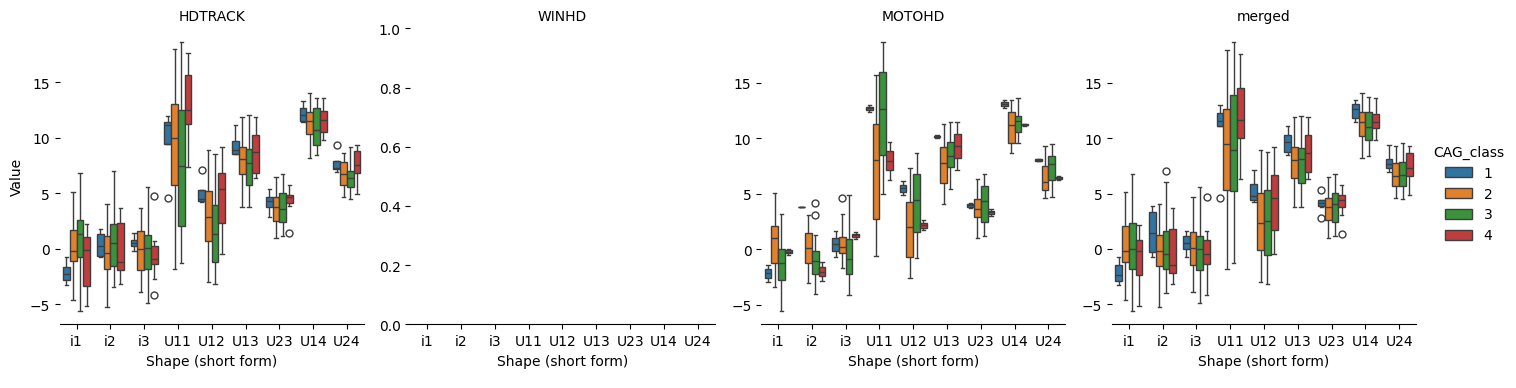

In [31]:
#################################  plotting box-plots  ###################################
class_variable = 'CAG_class' # Diag or CAG_class

# --- Label datasets ---
HDTRACK['Dataset'] = 'HDTRACK'
WINHD['Dataset'] = 'WINHD'
MOTOHD['Dataset'] = 'MOTOHD'
merged_info['Dataset'] = 'merged'

# --- Combine all datasets ---
combined = pd.concat([HDTRACK, WINHD, MOTOHD, merged_info])

# --- Reshape to long format for Seaborn ---
long = combined.melt(
    id_vars=[class_variable, 'Dataset'],    
    value_vars=[
        'iso1', 'iso2', 'iso3',
        'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'
    ],
    var_name='Iso',
    value_name='Value'
)

# --- Create shorthand mapping for x-axis ---
shorthand_labels = {
    'iso1': 'i1', 'iso2': 'i2', 'iso3': 'i3',
    'UMAP1_U1': 'U11', 'UMAP1_U2': 'U12', 'UMAP1_U3': 'U13', 'UMAP2_U3': 'U23',
    'UMAP1_U4': 'U14', 'UMAP2_U4': 'U24'
}

x_order = [shorthand_labels[key] for key in [
    'iso1', 'iso2', 'iso3',
    'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'
]]

# --- Replace 'Iso' names for display ---
long['Iso_short'] = long['Iso'].map(shorthand_labels)

# --- Plot faceted boxplots ---
g = sns.catplot(
    data=long, x='Iso_short', y='Value', hue=class_variable,    
    col='Dataset', kind='box',
    col_wrap=4,            # number of subplots per row
    height=4, aspect=0.9,
    sharey=False
)

# --- Basic styling ---
g.set_axis_labels("Shape (short form)", "Value")
g.set_titles("{col_name}")
g.despine(left=True)


# --- Ensure all facet axes show consistent x-tick labels (keep this) ---
for ax in g.axes.flat:
    ax.set_xticks(range(len(x_order)))
    ax.set_xticklabels(x_order)
    ax.tick_params(axis='x', which='both', labelbottom=True)

# --- Compute dynamic bottom margin based on how many rows of facets there are ---
n_rows = int(np.ceil(len(g.axes) / g._ncol))
# base bottom margin; increase with rows
bottom_margin = 0.12 + 0.06 * (n_rows - 1)

# give a bit more room so legend won't be clipped
bottom_margin_for_plot = bottom_margin + 0.06

# Adjust subplot spacing so the plot area leaves room for the legend
g.fig.subplots_adjust(hspace=0.5, bottom=bottom_margin_for_plot, top=0.92)

# --- Create legend and place it inside figure coordinates (won't be clipped) ---
handles, labels = g.axes[0].get_legend_handles_labels()

# place legend at half the bottom margin (in figure coordinates)
legend_y = bottom_margin / 2.0   # between 0 and 1 in fig coords; adjust if needed

# Use fig.transFigure so bbox_to_anchor is in figure coordinates (0..1)
legend = g.fig.legend(
    handles, labels,
    title="",
    loc='center',
    bbox_to_anchor=(0.5, legend_y),
    bbox_transform=g.fig.transFigure,
    ncol=3,
    frameon=False
)

# Optional: increase legend text size / spacing so it is readable
for text in legend.get_texts():
    text.set_fontsize(9)
#legend.set_title("Diagnosis")
#legend.get_title().set_fontsize(10)

# --- Save the Seaborn figure (use g.fig) ---
curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\{curProject}_{curRegion}_{curDistType}_k{curNeig}.png'
print(curPlotName)

# bbox_inches='tight' + small pad to avoid any tiny clipping
#g.fig.savefig(curPlotName, bbox_inches='tight', dpi=300, pad_inches=0.08)
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_10056\3681658844.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HDTRACK['Dataset'] = 'HDTRACK'
C:\Users\joyca\AppData\Local\Temp\ipykernel_10056\3681658844.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  WINHD['Dataset'] = 'WINHD'
C:\Users\joyca\AppData\Local\Temp\ipykernel_10056\3681658844.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

C:\B_projWIP\proj_HD\Analysis_2025\Plots\HD_CSpreCS_max_k30_CAGclass_U13_compare.png


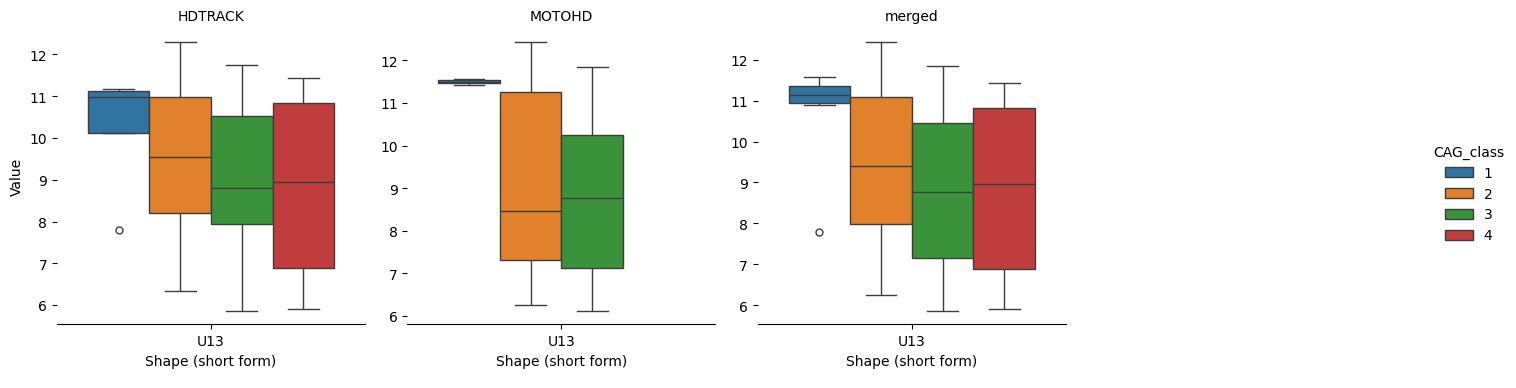

In [143]:
#######################  plotting box-plots, only selected variables, change legend  #########################
class_variable = 'CAG_class' # Diag or CAG_class

#cur_values = ['iso1', 'iso2', 'iso3']
#shorthand_labels = {'iso1': 'i1', 'iso2': 'i2', 'iso3': 'i3'}
#x_order = [shorthand_labels[key] for key in ['iso1', 'iso2', 'iso3']]

cur_values = ['UMAP1_U3']
shorthand_labels = {'UMAP1_U3': 'U13'}
x_order = [shorthand_labels[key] for key in ['UMAP1_U3']]

# --- Label datasets ---
HDTRACK['Dataset'] = 'HDTRACK'
WINHD['Dataset'] = 'WINHD'
MOTOHD['Dataset'] = 'MOTOHD'
merged_info['Dataset'] = 'merged'

# --- Selecting datasets ---
#combined = pd.concat([HDTRACK, WINHD, MOTOHD, merged_info])  # select all datasets
combined = pd.concat([HDTRACK, MOTOHD, merged_info]) 

# --- Reshape to long format for Seaborn ---
long = combined.melt(
    id_vars=[class_variable, 'Dataset'],
    value_vars = cur_values,
    var_name='Shape',
    value_name='Value'
)

# --- Replace 'Shape' names for display ---
long['Shape_short'] = long['Shape'].map(shorthand_labels)

if class_variable == 'Diag':
    # --- Rename legend label names ---
    long['Diag'] = long['Diag'].replace({
        'MH': 'Huntington',
        'MH_premanifest': 'UHDRS<5',
        'T': 'Control'
    })

# --- Plot faceted boxplots ---
g = sns.catplot(
    data=long, x='Shape_short', y='Value', hue=class_variable,
    col='Dataset', kind='box',
    col_wrap=4,            # number of subplots per row
    height=4, aspect=0.9,
    sharey=False
)

# --- Basic styling ---
g.set_axis_labels("Shape (short form)", "Value")
g.set_titles("{col_name}")
g.despine(left=True)



# --- Ensure all facet axes show consistent x-tick labels (keep this) ---
for ax in g.axes.flat:
    ax.set_xticks(range(len(x_order)))
    ax.set_xticklabels(x_order)
    ax.tick_params(axis='x', which='both', labelbottom=True)

# --- Compute dynamic bottom margin based on how many rows of facets there are ---
n_rows = int(np.ceil(len(g.axes) / g._ncol))
# base bottom margin; increase with rows
bottom_margin = 0.12 + 0.06 * (n_rows - 1)

# give a bit more room so legend won't be clipped
bottom_margin_for_plot = bottom_margin + 0.06

# Adjust subplot spacing so the plot area leaves room for the legend
g.fig.subplots_adjust(hspace=0.5, bottom=bottom_margin_for_plot, top=0.92)

# --- Create legend and place it inside figure coordinates (won't be clipped) ---
handles, labels = g.axes[0].get_legend_handles_labels()

# place legend at half the bottom margin (in figure coordinates)
legend_y = bottom_margin / 2.0   # between 0 and 1 in fig coords; adjust if needed

# Use fig.transFigure so bbox_to_anchor is in figure coordinates (0..1)
legend = g.fig.legend(
    handles, labels,
    title="",
    loc='center',
    bbox_to_anchor=(0.5, legend_y),
    bbox_transform=g.fig.transFigure,
    ncol=3,
    frameon=False
)

# Optional: increase legend text size / spacing so it is readable
for text in legend.get_texts():
    text.set_fontsize(9)
#legend.set_title("Diagnosis")
#legend.get_title().set_fontsize(10)

# --- Save the Seaborn figure (use g.fig) ---
curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\{curProject}_{curRegion}_{curDistType}_k{curNeig}_CAGclass_U13_compare.png'
print(curPlotName)

# bbox_inches='tight' + small pad to avoid any tiny clipping
#g.fig.savefig(curPlotName, bbox_inches='tight', dpi=300, pad_inches=0.08)
plt.show()

C:\B_projWIP\proj_HD\Analysis_2025\Plots\HD_CST_max_k30_Pyramidal_iso5_left.png


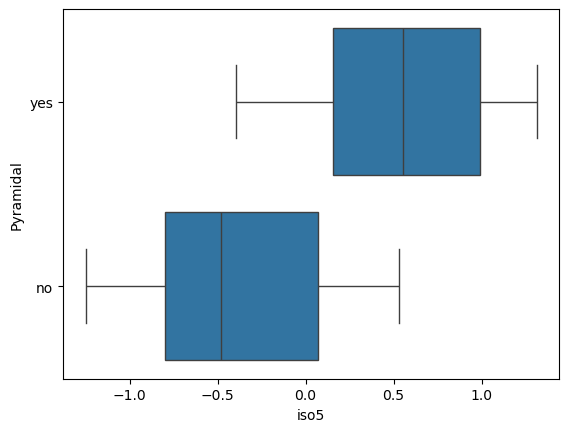

In [99]:
############################  Quick boxplot  #############################
cur_data = MOTOHD_left    # MOTOHD, merged_info
class_variable = 'Pyramidal'  # Diag, CAG_class, Pyramidal
curX = 'iso5' # iso2, UHDRS

sns.boxplot(data=cur_data, x=class_variable, y=curX)

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\{curProject}_{curRegion}_{curDistType}_k{curNeig}_Pyramidal_iso5_left.png'
print(curPlotName)
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
#plt.close()

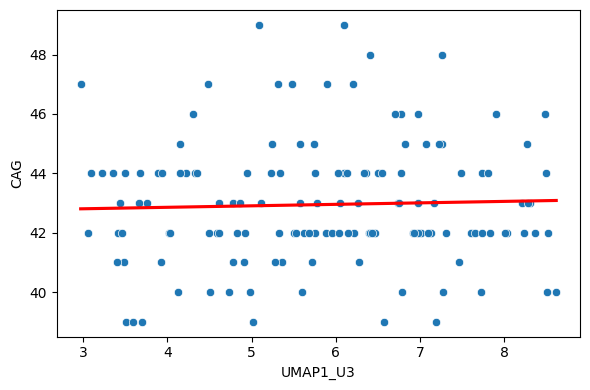

In [67]:
############################  Quick scatterplot  #############################
curX = 'UMAP1_U3'
curY = 'CAG'

plt.figure(figsize=(6,4))
sns.scatterplot(data=merged_info, x=curX, y=curY)                       # no jitter
#sns.stripplot(data=merged_info, x=curX, y=curY, jitter=0.2, orient='h')  # with jitter

# Regression line
sns.regplot(data=merged_info, x=curX, y=curY, scatter=False, ci=None, color='red')  # ONLY works when no jitter !

plt.tight_layout()
plt.show()


C:\B_projWIP\proj_HD\Analysis_2025\Plots\HD_CSpreCS_max_k30_U13_corCAG_jitter.png


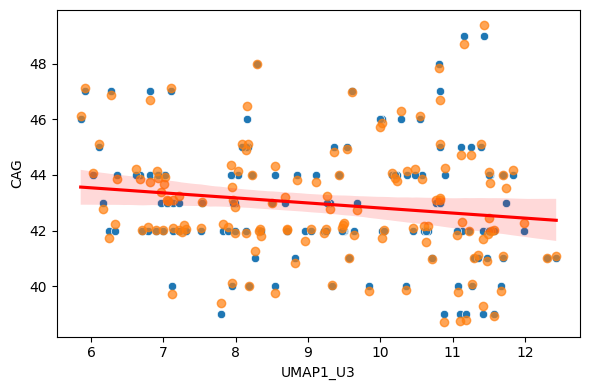

In [125]:
#################  scatter plots, blue original, orange with jitter, red regression line  ##################
curX = 'UMAP1_U3'
curY = 'CAG'

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=merged_info, x=curX, y=curY,
)

# Add jitter manually
import numpy as np
plt.scatter(
    merged_info[curX],
    merged_info[curY] + np.random.normal(0, 0.2, size=len(merged_info)),
    alpha=0.7
)

sns.regplot(data=merged_info, x=curX, y=curY, scatter=False, color='red')

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\{curProject}_{curRegion}_{curDistType}_k{curNeig}_U13_corCAG_jitter.png'
print(curPlotName)
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


C:\B_projWIP\proj_HD\Analysis_2025\Plots\HD_CSpreCS_max_k30_U13_CAG_removeOutlier.png


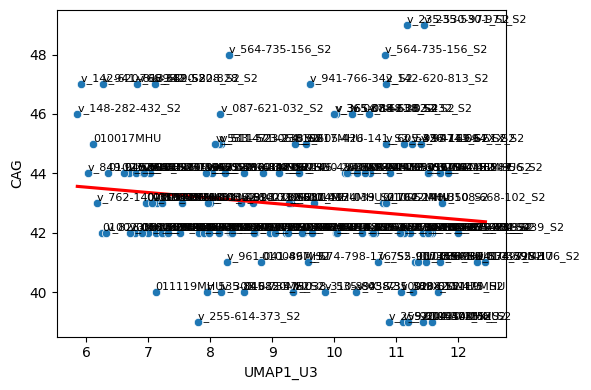

In [265]:
#####################  Quick scatterplot, display subject name  #######################
curX = 'UMAP1_U3'

plt.figure(figsize=(6,4))

# Scatter
sns.scatterplot(data=merged_info, x=curX, y='CAG')

# Regression line
sns.regplot(data=merged_info, x=curX, y='CAG',
            scatter=False, ci=None, color='red')

# Labels
for i, row in merged_info.iterrows():
    plt.text(row[curX], row['CAG'], str(row['SubjID']),
             fontsize=8, ha='left', va='bottom')
plt.tight_layout()

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\{curProject}_{curRegion}_{curDistType}_k{curNeig}_U13_CAG_removeOutlier.png'
print(curPlotName)
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')

plt.show()


In [273]:
######################################  Parametric linear model  #######################################

In [401]:
#########################################  Quick confirmation, LM ##########################################
cur_info = HDTRACK_MOTOHD    # merged_info, MOTOHD, HDTRACK_MOTOHD
shape_measures = ['UMAP1_U3'] # 'UHDRS','iso2', 'UMAP1_U3', 'UMAP1_U4', 'UMAP2_U4'

# Dictionary to store results
model_results = {}

for measure in shape_measures:
    #formula = f'{measure} ~ UHDRS + Age + C(Sex) + C(Hemisphere)'
    #formula = f'{measure} ~ UHDRS + CAG + Age + C(Sex) + C(Hemisphere)'
    #formula = f'{measure} ~ C(Pyramidal) + Age + C(Sex) + C(Hemisphere)'
    #formula = f'{measure} ~ C(Pyramidal) + CAG + Age + C(Sex) + C(Hemisphere)'
    #formula = f'{measure} ~ CAG + C(Pyramidal) + Age + C(Sex) + C(Hemisphere)'  # test changing order compare to line above, didn't change result  
    #formula = f'{measure} ~ Pyramidal + Age + Sex + Hemisphere'  # only one study has pyramidal info        
    #formula = f'{measure} ~ Diag + Age + Sex + Hemisphere + Study'
    formula = f'{measure} ~ CAG + Age + Sex + Hemisphere + Study'   
    #formula = f'{measure} ~ CAG + Age + Sex + Hemisphere'   
    
    model = smf.ols(formula, data=cur_info).fit()
    model_results[measure] = model
    print(f'========================= Results for {measure} ===========================')
    print(model.summary())
    print('\n')

========================= Results for UMAP1_U3 ===========================
                            OLS Regression Results                            
Dep. Variable:               UMAP1_U3   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     2.581
Date:                Mon, 08 Dec 2025   Prob (F-statistic):             0.0290
Time:                        20:19:56   Log-Likelihood:                -273.59
No. Observations:                 140   AIC:                             559.2
Df Residuals:                     134   BIC:                             576.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

In [81]:
############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################
# Define the dataset
cur_info = MOTOHD  # merged_info,MOTOHD

#######################  LM tests, parametric  ########################
# List of shape measures
shape_measures = ['iso1', 'iso2', 'iso3','iso4','iso5','iso6', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP1_U4','UMAP2_U3','UMAP2_U4']

# Dictionary to store results
model_results = {}

for measure in shape_measures:
    #formula = f'{measure} ~ Diag + Age + Sex + Hemisphere'
    #formula = f'{measure} ~ Diag + Age + Sex + Hemisphere + Study'    
    formula = f'{measure} ~ C(Pyramidal) + Age + C(Sex) + C(Hemisphere)'  # only one study has pyramidal info    
    #formula = f'{measure} ~ C(Pyramidal) + CAG + Age + C(Sex) + C(Hemisphere)'  # only one study has pyramidal info      
    #formula = f'{measure} ~ CAG + Age + C(Sex) + C(Hemisphere) + C(Study)'   
    #formula = f'{measure} ~ CAG_class + Age + Sex + Hemisphere + Study' 
    
    model = smf.ols(formula, data=cur_info).fit()
    model_results[measure] = model
    print(f'========================= Results for {measure} ===========================')
    print(model.summary())
    print('\n')

========================= Results for iso1 ===========================
                            OLS Regression Results                            
Dep. Variable:                   iso1   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     4.536
Date:                Thu, 22 Jan 2026   Prob (F-statistic):            0.00441
Time:                        13:41:11   Log-Likelihood:                -78.947
No. Observations:                  42   AIC:                             167.9
Df Residuals:                      37   BIC:                             176.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

In [393]:
######################  Check VIF  #####################
cur_info = HDTRACK

from statsmodels.stats.outliers_influence import variance_inflation_factor

measure = 'UMAP1_U3' # iso2, UMAP2_U3
#formula = f'{measure} ~ C(Pyramidal) + Age + C(Sex) + CAG + C(Hemisphere)'
formula = f'{measure} ~ Age + C(Sex) + CAG + C(Hemisphere)'

model = smf.ols(formula, data=cur_info).fit()
model_results[measure] = model
print(f'========================= Results for {measure} ===========================')
print(model.summary())
print('\n')

X = model.model.exog
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif["variable"] = model.model.exog_names
print(vif)


========================= Results for UMAP1_U3 ===========================
                            OLS Regression Results                            
Dep. Variable:               UMAP1_U3   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.302
Date:                Mon, 08 Dec 2025   Prob (F-statistic):              0.275
Time:                        20:14:48   Log-Likelihood:                -194.50
No. Observations:                 100   AIC:                             399.0
Df Residuals:                      95   BIC:                             412.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [361]:
#######################  check for simple correlations, when there are categorical variables  #######################
cur_info = MOTOHD

from scipy.stats import pointbiserialr
cur_info['Pyramidal_binary'] = cur_info['Pyramidal'].map({'no': 0, 'yes': 1})
corr, p = pointbiserialr(cur_info['Pyramidal_binary'], cur_info['CAG'])
print ('Pyramidal cor CAG')
print(corr, p)

corr, p = pointbiserialr(cur_info['Pyramidal_binary'], cur_info['UHDRS'])
print ('Pyramidal cor UHDRS')
print(corr, p)

corr, p = pointbiserialr(cur_info['UHDRS'], cur_info['CAG'])
print ('UHDRS cor CAG')
print(corr, p)   

print('##############################################')

corr, p = pointbiserialr(cur_info['Pyramidal_binary'], cur_info['iso2'])
print ('Pyramidal cor iso2')
print(corr, p)

corr, p = pointbiserialr(cur_info['UHDRS'], cur_info['iso2'])
print ('UHDRS cor iso2')
print(corr, p)       

corr, p = pointbiserialr(cur_info['CAG'], cur_info['iso2'])
print ('CAG cor iso2')
print(corr, p)  

print('##############################################')

corr, p = pointbiserialr(cur_info['CAG'], cur_info['Age'])
print ('CAG cor Age')
print(corr, p)  

Pyramidal cor CAG
0.15131451275975022 0.3578215498190443
Pyramidal cor UHDRS
0.1255517664171508 0.4463098236850567
UHDRS cor CAG
0.05417518087731488 0.7432466051723675
##############################################
Pyramidal cor iso2
-0.06718159776444653 0.684479307886629
UHDRS cor iso2
-0.015296425543003825 0.926361601567112
CAG cor iso2
0.2809170974181032 0.08321583476629377
CAG cor Age
-0.35317342092239623 0.027424421027254606


C:\Users\joyca\AppData\Local\Temp\ipykernel_13780\3835666286.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cur_info['Pyramidal_binary'] = cur_info['Pyramidal'].map({'no': 0, 'yes': 1})


In [323]:
#########################  Calculate the correlation matrix, numerical only  ########################

cur_info = MOTOHD
cur_info.drop(['iso1','iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4'], axis=1,inplace=True)

print('###################  Correllation matrix  ################### ')
print(cur_info.columns)
cur_info.shape
cur_info.dtypes
df_numeric = cur_info.select_dtypes(include=['number'])  # ONLY between numeric variables
df_numeric.corr()
#print(cur_info.corr)

###################  Correllation matrix  ################### 
Index(['subjName', 'iso2', 'SubjID', 'Study', 'Hemisphere', 'Age', 'Diag',
       'Sex', 'CAG', 'UHDRS', 'Pyramidal', 'CAG_normalAllele', 'Sex_num',
       'Hemisphere_num', 'CAG_class', 'Pyramidal_binary'],
      dtype='object')


C:\Users\joyca\AppData\Local\Temp\ipykernel_13780\3586079916.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cur_info.drop(['iso1','iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4'], axis=1,inplace=True)


,iso2,Age,CAG,UHDRS,CAG_normalAllele,Sex_num,Hemisphere_num,Pyramidal_binary
iso2,1.000000,1.705762e-01,-3.737013e-01,-2.909359e-02,NaN,1.436965e-01,-4.157120e-02,-3.194546e-01
Age,0.170576,1.000000e+00,-3.274887e-01,3.328762e-01,NaN,-4.510386e-01,5.233452e-17,1.003739e-01
CAG,-0.373701,-3.274887e-01,1.000000e+00,1.116346e-01,NaN,3.880141e-01,-5.377864e-15,1.683451e-01
UHDRS,-0.029094,3.328762e-01,1.116346e-01,1.000000e+00,NaN,-3.554883e-01,-5.004318e-17,1.583993e-01
CAG_normalAllele,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex_num,0.143696,-4.510386e-01,3.880141e-01,-3.554883e-01,NaN,1.000000e+00,-1.529707e-16,4.279605e-02
Hemisphere_num,-0.041571,5.233452e-17,-5.377864e-15,-5.004318e-17,NaN,-1.529707e-16,1.000000e+00,-1.163830e-17
Pyramidal_binary,-0.319455,1.003739e-01,1.683451e-01,1.583993e-01,NaN,4.279605e-02,-1.163830e-17,1.000000e+00


In [357]:
#########################################   Likelihood ratio test  ###########################################
# comparing log-likelihoods of nested models, for small sample size and the testing of a key effect
# Use reml=False for both models. REML (restricted maximum likelihood) is good for estimating variance components
# but not for comparing models with different fixed effects.
# Using a chi-square distribution with df=1 because testing 1 parameter (eg. Pyramidal, CAG).   

df = MOTOHD

from scipy.stats import chi2

# FULL MODEL: includes the variate (the key effect)
model_full = smf.ols(
    "iso2 ~ C(Pyramidal) + Age + C(Sex) + C(Hemisphere)",  # Test Pyramidal
#    "iso2 ~ C(Pyramidal) + UHDRS + Age + C(Sex) + C(Hemisphere)",  # Test UHDRS   
#    "iso2 ~ C(Pyramidal) + CAG + Age + C(Sex) + C(Hemisphere)",  # Test CAG 
#    "iso2 ~ C(Pyramidal) * CAG + Age + C(Sex) + C(Hemisphere)",  # Test Pyramidal*CAG     
    data=df
)
result_full = model_full.fit(reml=False)  # Use ML (not REML) for model comparison

# REDUCED MODEL: same as above, but WITHOUT the variate
model_reduced = smf.ols(
    "iso2 ~ Age + C(Sex) + C(Hemisphere)",   # Test Pyramidal
#    "iso2 ~ C(Pyramidal) + Age + C(Sex) + C(Hemisphere)",  # Test UHDRS  
#    "iso2 ~ C(Pyramidal) + Age + C(Sex) + C(Hemisphere)",  # Test CAG   
#    "iso2 ~ C(Pyramidal) + CAG + Age + C(Sex) + C(Hemisphere)",  # Test Pyramidal*CAG      
    data=df
)
result_reduced = model_reduced.fit(reml=False)

# LRT statistic
lrt_stat = 2 * (result_full.llf - result_reduced.llf)

# df = number of parameters removed (1 parameter)
p_value = chi2.sf(lrt_stat, df=1)

# Print results
print(f"Likelihood Ratio Test statistic: {lrt_stat:.4f}")
print(f"p-value: {p_value:.4g}")

if p_value < 0.05:
    print(" Variate significantly improves the model (reject null hypothesis).")
else:
    print(" No significant effect of variate.")

Likelihood Ratio Test statistic: 0.1426
p-value: 0.7057
 No significant effect of variate.


In [37]:
cur_info.columns

Index(['subjName', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3',
       'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'SubjID', 'Study', 'Hemisphere',
       'Age', 'Diag', 'Sex', 'CAG', 'UHDRS', 'Pyramidal', 'CAG_normalAllele',
       'Sex_num', 'Hemisphere_num'],
      dtype='object')

In [153]:
#################################  Quick confirmation, LMM  ###################################
cur_info = merged_info

shape_measures = ['UMAP1_U3'] # 'iso3', 'UMAP1_U3', 'UMAP1_U4', 'UMAP2_U4'
# Dictionary to store results
model_results = {}

for measure in shape_measures:
    formula = f'{measure} ~ Pyramidal + Age + Sex + Hemisphere'
    
    model = smf.mixedlm(
        formula,
        data=cur_info,
        groups=cur_info["SubjID"]
    ).fit()

    model_results[measure] = model
    print(f'========================= Results for {measure} ===========================')
    print(model.summary())
    print('\n')


IndexError: index 62 is out of bounds for axis 0 with size 42

In [57]:
##############################  naive post hoc with no covariates  ####################################
# Tukey HSD
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Drop missing values in the columns used
cur_info_clean = cur_info.dropna(subset=['iso3', 'Diag']).copy()
# Make sure groups are strings or categories
cur_info_clean['Diag'] = cur_info_clean['Diag'].astype(str)

# Run Tukey HSD
tukey = pairwise_tukeyhsd(
    endog=cur_info_clean['iso3'],   # dependent variable
    groups=cur_info_clean['Diag'],  # group labels
    alpha=0.05
)

print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
    group1     group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------------
MH_premanifest      T   1.6589 0.0045 0.5358 2.7819   True
----------------------------------------------------------


In [157]:
##############################  post hoc with covariates  ####################################
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#def run_models_with_posthoc(data, measures, covariates=['Age', 'Sex','Hemisphere']):
def run_models_with_posthoc(data, measures, covariates=['Age', 'Sex','Hemisphere','Study']):
    results = []
    for measure in measures:
        # Build formula
        formula = f"{measure} ~ Diag + {' + '.join(covariates)}"
        model = smf.ols(formula, data=data).fit()
        # Run Tukey HSD on Group
        tukey = pairwise_tukeyhsd(
            endog=data[measure],
#            groups=data['Diag'],
            groups=data['CAG_class'],            
#            groups=data['Pyramidal'],
            alpha=0.05
        )
        # Store results in DataFrame
        tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
        tukey_df["Measure"] = measure  # tag which dependent variable
        results.append(tukey_df)
    # Combine all results
    return pd.concat(results, ignore_index=True)

# Drop missing values in the columns used
#cur_info = merged_info

cur_info_clean = cur_info.dropna(subset=['iso3', 'Diag']).copy()
# Make sure groups are strings or categories
cur_info_clean['Diag'] = cur_info_clean['Diag'].astype(str)

#measures = ["iso2", "UMAP1_U2", "UMAP2_U3"]  # min, missing_hem
measures = ["UMAP1_U3"]  # GM_thickness,opening, min, missing_hem
posthoc_results = run_models_with_posthoc(cur_info_clean, measures)

print("\nAll Post-hoc Results:")
print(posthoc_results)


All Post-hoc Results:
   group1  group2  meandiff   p-adj   lower   upper  reject   Measure
0     1.0     2.0   -1.3767  0.3495 -3.4260  0.6726   False  UMAP1_U3
1     1.0     3.0   -1.7633  0.1277 -3.8096  0.2830   False  UMAP1_U3
2     1.0     4.0   -1.6111  0.4279 -4.1959  0.9738   False  UMAP1_U3
3     1.0     NaN   -1.5514  0.2125 -3.5570  0.4542   False  UMAP1_U3
4     2.0     3.0   -0.3866  0.7363 -1.2533  0.4802   False  UMAP1_U3
5     2.0     4.0   -0.2344  0.9965 -2.0358  1.5671   False  UMAP1_U3
6     2.0     NaN   -0.1747  0.9706 -0.9404  0.5910   False  UMAP1_U3
7     3.0     4.0    0.1522  0.9993 -1.6458  1.9503   False  UMAP1_U3
8     3.0     NaN    0.2119  0.9393 -0.5457  0.9695   False  UMAP1_U3
9     4.0     NaN    0.0597  1.0000 -1.6919  1.8113   False  UMAP1_U3


C:\B_projWIP\proj_HD\Analysis_2025\Plots\2024_iso2_CS_min_congAmpCtr_Box_Both.png


C:\Users\joyca\AppData\Local\Temp\ipykernel_4924\1936650362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


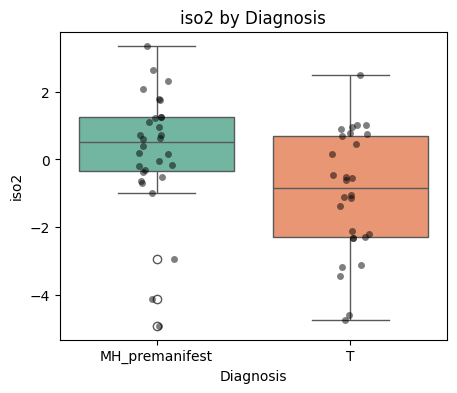

In [53]:
#####################  Boxplot of Raw Data  #####################
measure = 'iso2'      # opening, GM_thickness,  # <-- choose the measure you want
group_col = 'Diag'

plt.figure(figsize=(5, 4))
sns.boxplot(
    data=WINHD,
    x=group_col,
    y=measure,
    palette='Set2'
)
sns.stripplot(
    data=WINHD,
    x=group_col,
    y=measure,
    color='black',
    alpha=0.5,
    jitter=True
)
plt.title(f'{measure} by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel(measure)

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\2024_{measure}_{curRegion}_{curDistType}_congAmpCtr_Box_Both.png'
print(curPlotName)
#plt.savefig(curPlotName)

plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_5564\2622563968.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cur_info, x="Diag", y="iso3", inner="box", palette="Set2")


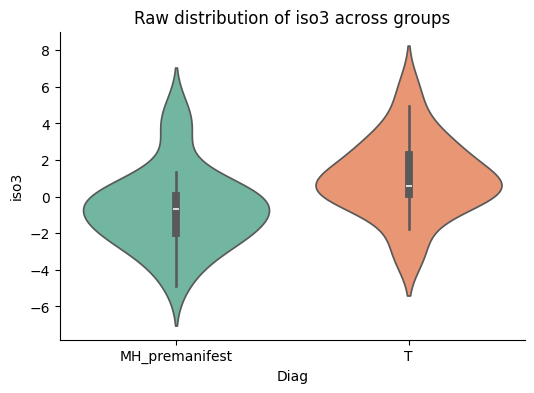

In [290]:
#####################  Violin of Raw Data  #####################

plt.figure(figsize=(6,4))
sns.violinplot(data=cur_info, x="Diag", y="iso3", inner="box", palette="Set2")
plt.title("Raw distribution of iso3 across groups")
plt.ylabel("iso3")
sns.despine()
plt.show()


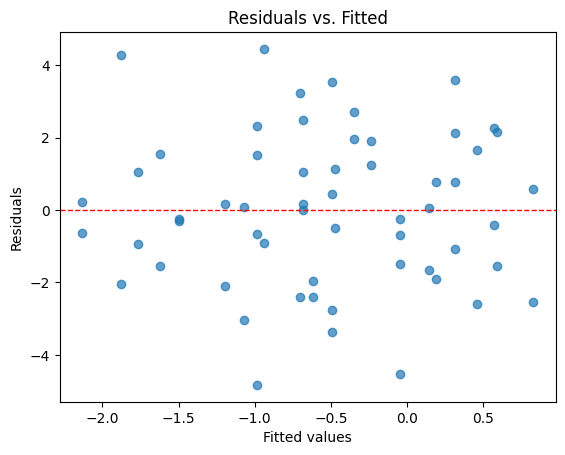

In [204]:
model = None

############################  Model diagnostics  #############################
#	Linearity: residuals vs. fitted plot should have no curve

# Fit model
formula = "iso3 ~ Diag + Age + Sex"
model = smf.ols(formula, data=cur_info).fit()

# Get fitted values and residuals
fitted_vals = model.fittedvalues
residuals = model.resid

# Plot residuals vs. fitted
plt.scatter(fitted_vals, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted")
plt.show()


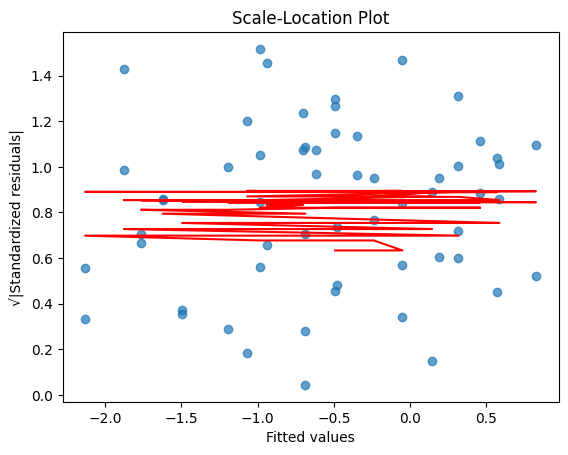

In [206]:
#	Homoscedasticity: scale-location plot (residuals vs. fitted with equal spread)
# Get fitted values and standardized residuals
fitted_vals = model.fittedvalues
residuals = model.resid
standardized_resid = residuals / np.std(residuals)

# Square root of absolute standardized residuals
sqrt_abs_resid = np.sqrt(np.abs(standardized_resid))

plt.scatter(fitted_vals, sqrt_abs_resid, alpha=0.7)
sm.nonparametric.lowess(sqrt_abs_resid, fitted_vals)  # add smoothing line
plt.plot(fitted_vals, sm.nonparametric.lowess(sqrt_abs_resid, fitted_vals)[:, 1], color="red")

plt.xlabel("Fitted values")
plt.ylabel("√|Standardized residuals|")
plt.title("Scale-Location Plot")
plt.show()

In [208]:
############################  For linearity: Ramsey RESET test  ##############################
# Look at the Residuals vs. fitted (no systematic curvature).
# Ramsey RESET test (general test of mis-specification):
# If p < 0.05 → possible nonlinearity / omitted variables.
    
from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(model, power=2, use_f=True)
print(reset_test)


<F test: F=0.009681333582549616, p=0.9219908142804165, df_denom=53, df_num=1>


In [210]:
################### Testing heteroscedasticity  ####################
# Breusch–Pagan test
# if p < 0.05, heteroscedasticity might exist
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['Lagrange multiplier statistic', 'p-value', 
          'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))


{'Lagrange multiplier statistic': 0.03268101614799801, 'p-value': 0.9998679393963962, 'f-value': 0.010148102430402506, 'f p-value': 0.9985814189344525}


In [212]:
################### Testing heteroscedasticity  ####################
# White test (more general, allows for nonlinearities)
from statsmodels.stats.diagnostic import het_white

white_test = het_white(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, white_test)))


{'LM Statistic': 1.9409257159165612, 'LM-Test p-value': 0.963037452329331, 'F-Statistic': 0.24730617283179085, 'F-Test p-value': 0.9707543805734119}


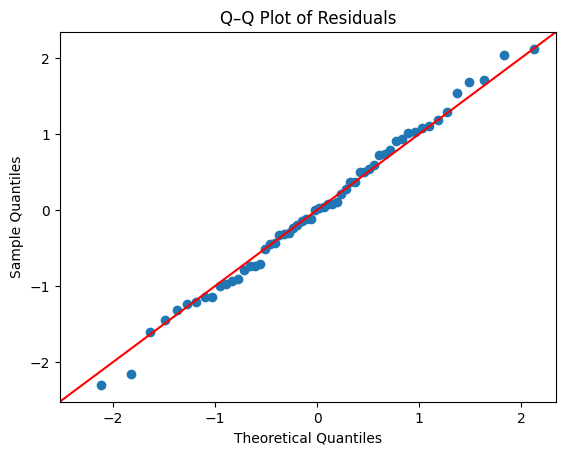

In [214]:
#	Normality of residuals: Q–Q plot, 

# Get residuals from your fitted model
residuals = model.resid

# Q–Q plot
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

In [216]:
# Shapiro–Wilk test (though with large n, visual inspection is better)
# Why “visual inspection is better with large n”?
# With a large sample size (say, n > 50–100), the Shapiro–Wilk test becomes too sensitive: 
#    it will flag tiny, irrelevant deviations as significant.
#    in practice, researchers rely more on Q–Q plots and also consider robustness of their model 
#       (linear regression is fairly robust to mild non-normality if sample size is big enough)

from scipy.stats import shapiro
stat, p = shapiro(residuals)
print('Shapiro-Wilk Test statistic=%.3f, p-value=%.3f' % (stat, p))

if p > 0.05:
    print("Residuals look normally distributed (fail to reject H0).")
else:
    print("Residuals are not normally distributed (reject H0).")

Shapiro-Wilk Test statistic=0.991, p-value=0.954
Residuals look normally distributed (fail to reject H0).


In [218]:
###################  Heteroscedasticity Alternative Model  ####################
# Use robust standard errors:
robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   iso3   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     2.913
Date:                Wed, 12 Nov 2025   Prob (F-statistic):             0.0296
Time:                        13:54:57   Log-Likelihood:                -125.35
No. Observations:                  58   AIC:                             258.7
Df Residuals:                      54   BIC:                             266.9
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [ ]:
print(cur_info.columns)

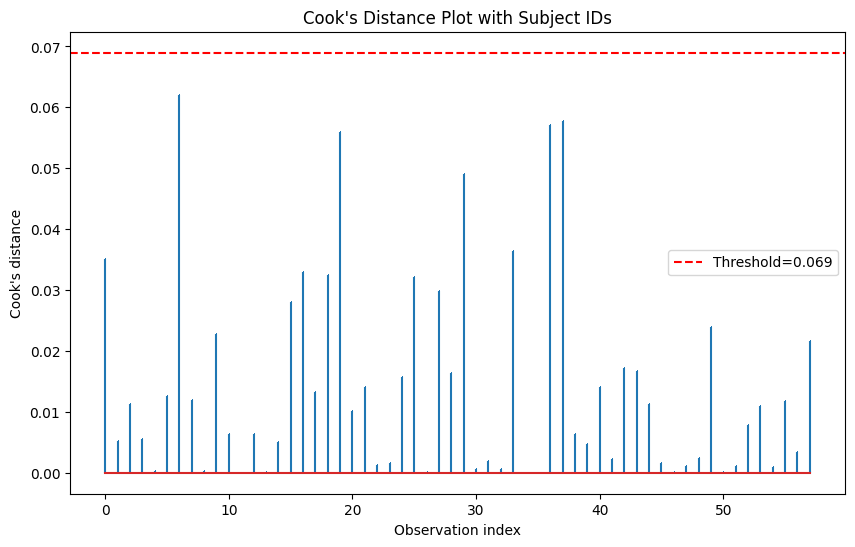

In [220]:
########################################  Influence studies  ########################################
## Cook's distance

# Influence measures
influence = model.get_influence()
cooks_d, pvals = influence.cooks_distance

# Subject IDs
#subject_ids = cur_info['SubjID'].astype(str).tolist()   # display SubjID
#subject_ids = cur_info.index.astype(str).tolist()       # display index, to compare with the influence plot below
subject_ids = cur_info['subjName'].astype(str).tolist()  # default: display subjName

# Plot Cook's distance
plt.figure(figsize=(10, 6))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt=",")  # no use_line_collection

# Custom red line: default = 4/n
n = len(cooks_d)
threshold = 4/n
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold={threshold:.3f}')

# Annotate IDs for influential points
for i, d in enumerate(cooks_d):
    if d > threshold:
        plt.text(i, d, subject_ids[i], fontsize=8, ha='right', va='bottom')

plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's Distance Plot with Subject IDs")
plt.legend()
plt.show()


In [222]:
# Create a mapping DataFrame
index_map = cur_info.reset_index()[['index', 'subjName', 'SubjID']]

# Rename the columns for clarity
index_map.columns = ['RowIndex', 'SubjName', 'SubjID']

pd.set_option('display.max_rows', None)
print(index_map)


    RowIndex                  SubjName              SubjID
0          4       LWINHD_001_17_LH_S3  WINHD_001_17_LH_S3
1         14       LWINHD_001_22_LA_S3  WINHD_001_22_LA_S3
2         20       LWINHD_001_09_FM_S3  WINHD_001_09_FM_S3
3         29       LWINHD_001_29_DW_S3  WINHD_001_29_DW_S3
4         35       LWINHD_001_24_MF_S3  WINHD_001_24_MF_S3
5         40       LWINHD_001_21_DJ_S3  WINHD_001_21_DJ_S3
6         41       LWINHD_001_01_RO_S3  WINHD_001_01_RO_S3
7         53       LWINHD_001_30_BA_S3  WINHD_001_30_BA_S3
8         57       LWINHD_001_26_BJ_S3  WINHD_001_26_BJ_S3
9         58       LWINHD_001_10_RF_S3  WINHD_001_10_RF_S3
10        63       LWINHD_001_06_MJ_S3  WINHD_001_06_MJ_S3
11        64       LWINHD_001_03_DA_S3  WINHD_001_03_DA_S3
12        66       LWINHD_001_27_VA_S3  WINHD_001_27_VA_S3
13        67       LWINHD_001_15_AC_S3  WINHD_001_15_AC_S3
14        68       LWINHD_001_20_MF_S3  WINHD_001_20_MF_S3
15        72       LWINHD_001_12_PE_S3  WINHD_001_12_PE_

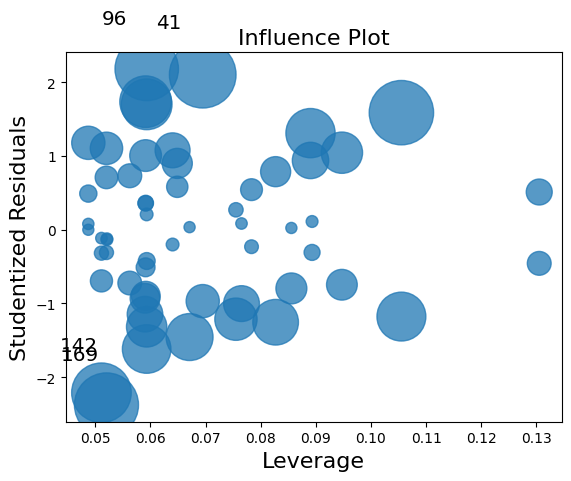

In [224]:
########################################  Influence studies  ########################################
## Leverage vs. residuals squared plot
sm.graphics.influence_plot(model, criterion="cooks")
plt.show()